In [2]:
import pandas as pd

INPUT_PATH = "time_series_health_data.csv"

def load_data():
    df = pd.read_csv(INPUT_PATH)
    print(f"Dataset shape: {df.shape}")
    return df

df = load_data()

Dataset shape: (97986, 6)


In [8]:
df.head()

,timestamp,patient_id,temperature,heart_rate,blood_oxygen,status
0,900,V3,35.100002,67.000000,100.0,healthy
1,930,V3,35.100002,66.847727,100.0,healthy
2,960,V3,35.100002,67.690909,100.0,healthy
3,990,V3,35.200001,65.550000,100.0,healthy
4,1020,V3,35.200001,64.409091,99.0,healthy


In [3]:
unique_patient_count = df['patient_id'].nunique()

patient_row_counts = df['patient_id'].value_counts()

print(f"Total Unique Patients: {unique_patient_count}")

print(f"\nAverage records per patient: {patient_row_counts.mean():.2f}")

Total Unique Patients: 386

Average records per patient: 253.85



===== DATA OVERVIEW =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97986 entries, 0 to 97985
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     97986 non-null  datetime64[ns]
 1   patient_id    97986 non-null  object        
 2   temperature   97986 non-null  float64       
 3   heart_rate    97986 non-null  float64       
 4   blood_oxygen  97986 non-null  float64       
 5   status        97986 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(3), object(1)
memory usage: 3.8+ MB
None

===== DESCRIPTIVE STATISTICS =====
                           timestamp   temperature    heart_rate  blood_oxygen
count                          97986  97986.000000  97986.000000  97986.000000
mean   1970-01-01 01:53:09.429306227     36.112180     72.362218     98.324918
min              1970-01-01 00:00:00     34.819846     31.366400     80.607997
25%              1970-01

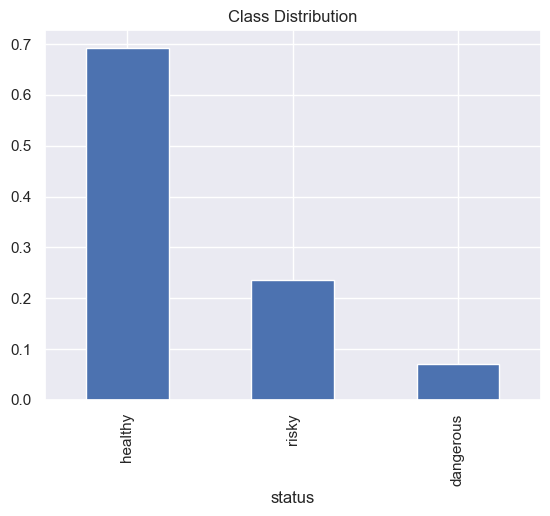

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme()

# Ensure correct datatypes
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')
df['patient_id'] = df['patient_id'].astype(str)
df['status'] = df['status'].astype('category')

# Sort 
df = df.sort_values("timestamp").reset_index(drop=True)

print("\n===== DATA OVERVIEW =====")
print(df.info())

print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== STATUS DISTRIBUTION =====")
print(df['status'].value_counts())


print("\n=== CLASS DISTRIBUTION ===")
dist = df['status'].value_counts(normalize=True)
print(dist)

dist.plot(kind='bar')
plt.title("Class Distribution")
plt.show()


=== PER-CLASS STATS ===
           temperature  heart_rate  blood_oxygen
status                                          
dangerous    36.746432   91.345070     93.310737
healthy      35.975072   68.609077     99.288361
risky        36.323822   77.670749     97.004437

=== VITAL DISTRIBUTIONS ===


/var/folders/8h/6qxl384s0s7cfqkmsr1mcxl80000gn/T/ipykernel_39046/460593165.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('status')[['temperature', 'heart_rate', 'blood_oxygen']].mean()


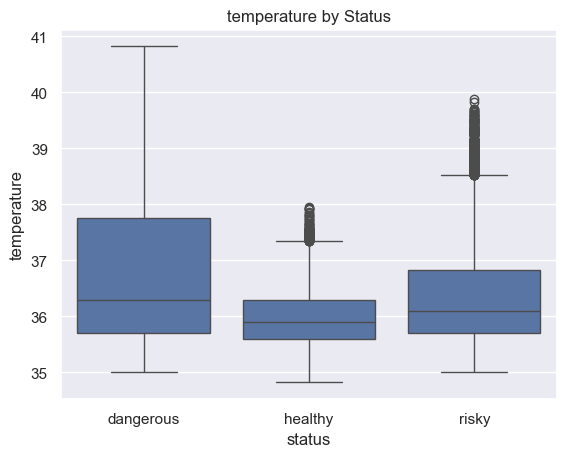

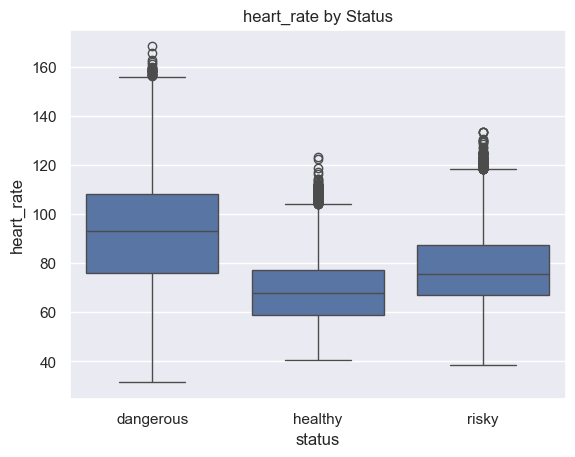

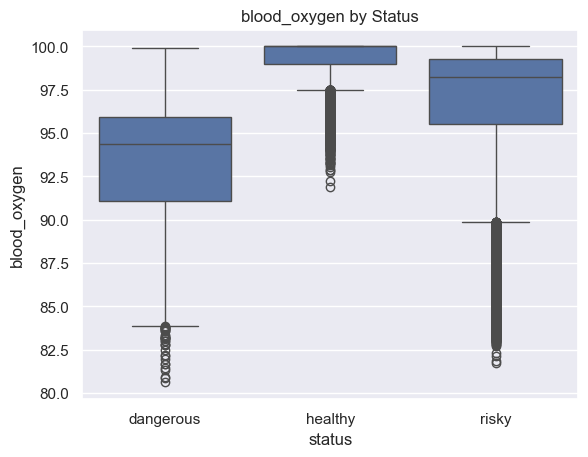

In [6]:
print("\n=== PER-CLASS STATS ===")
stats = df.groupby('status')[['temperature', 'heart_rate', 'blood_oxygen']].mean()
print(stats)

print("\n=== VITAL DISTRIBUTIONS ===")

cols = ['temperature', 'heart_rate', 'blood_oxygen']

for col in cols:
    plt.figure()
    sns.boxplot(x='status', y=col, data=df)
    plt.title(f"{col} by Status")
    plt.show()

All records: 97986
        temperature    heart_rate  blood_oxygen
count  97986.000000  97986.000000  97986.000000
mean      36.112180     72.362218     98.324918
std        0.708199     15.660104      2.677244
min       34.819846     31.366400     80.607997
25%       35.600002     61.000000     98.000000
50%       36.000000     70.000000     99.035954
75%       36.433665     81.000000    100.000000
max       40.820160    168.252988    100.000000


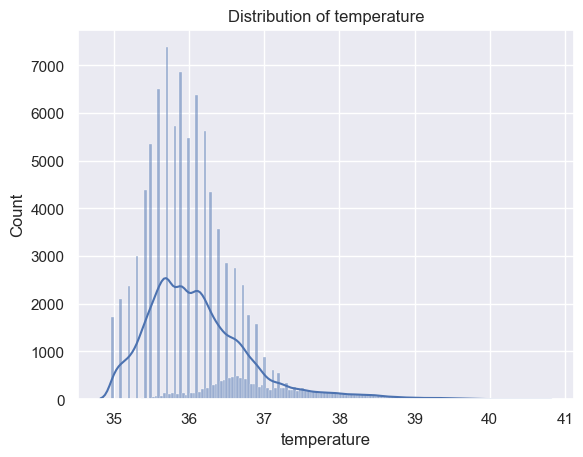

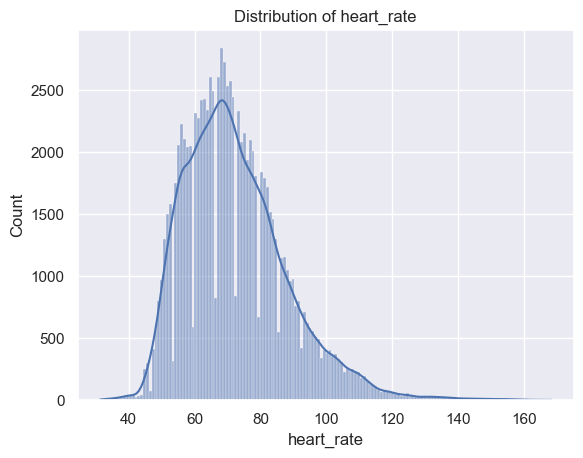

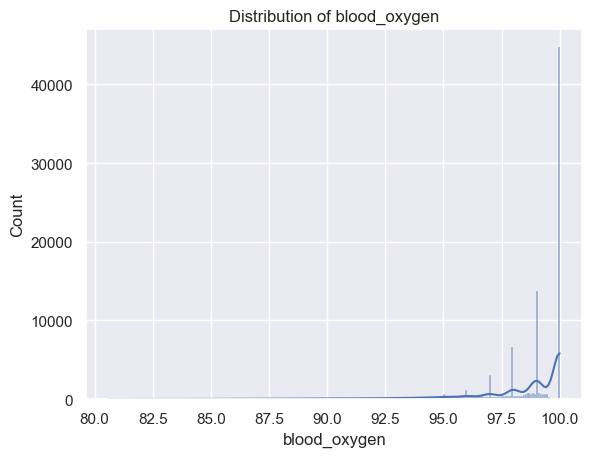

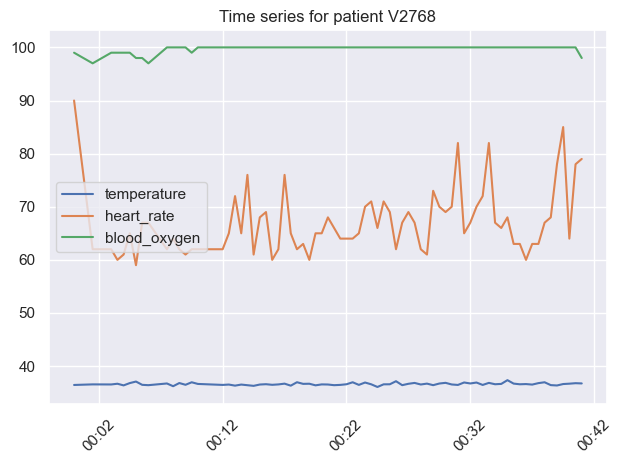

In [10]:
import matplotlib.dates as mdates

numeric_cols = ['temperature', 'heart_rate', 'blood_oxygen']

print(f"All records: {len(df)}")
print(df[numeric_cols].describe())

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.show()

# example time series for a single patient
sample_id = df['patient_id'].iloc[0]
sample = df[df['patient_id'] == sample_id]

plt.figure()
for col in numeric_cols:
    plt.plot(sample['timestamp'], sample[col], label=col)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
plt.title(f"Time series for patient {sample_id}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Healthy records: 67866
        temperature    heart_rate  blood_oxygen
count  67866.000000  67866.000000  67866.000000
mean      35.975072     68.609077     99.288361
std        0.506411     12.323463      1.079896
min       34.819846     40.662973     91.904111
25%       35.600002     59.000000     99.000000
50%       35.900002     67.809241    100.000000
75%       36.299999     77.000000    100.000000
max       37.959482    123.172698    100.000000


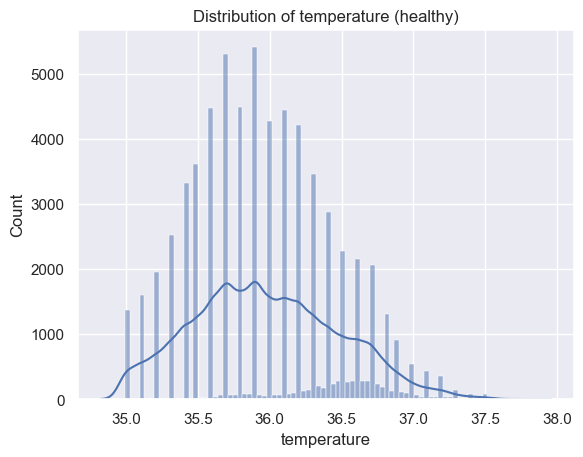

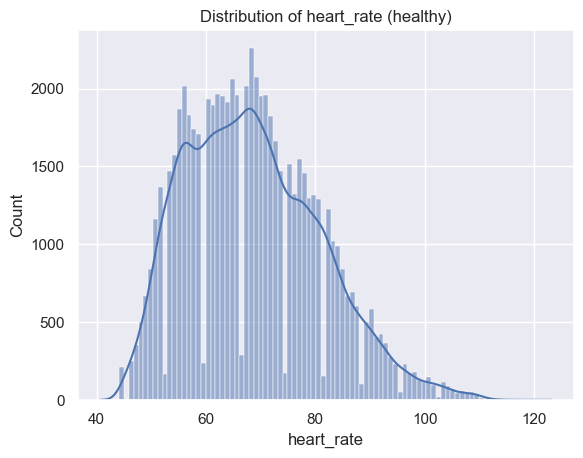

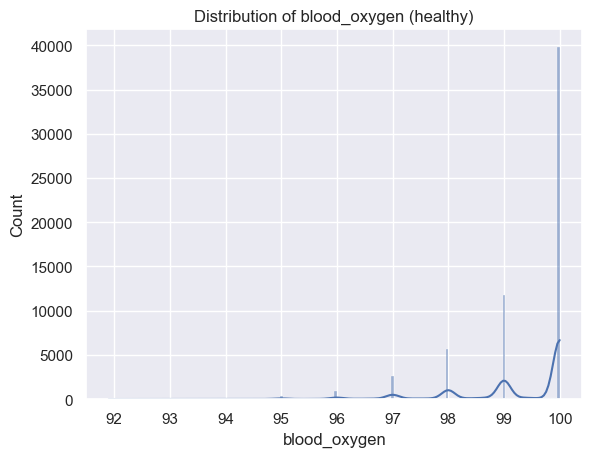

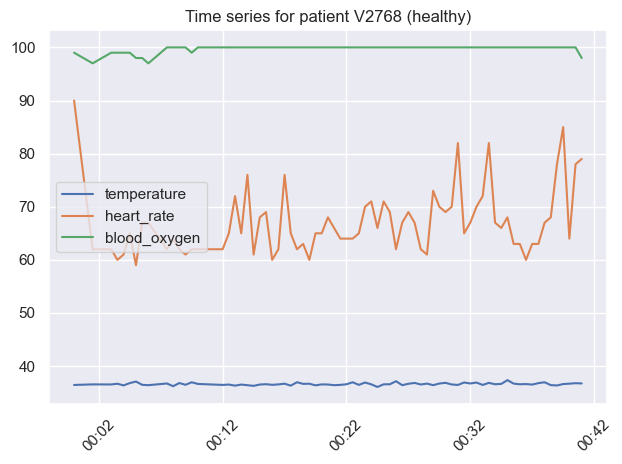

In [12]:
healthy = df[df['status'] == 'healthy']

numeric_cols = ['temperature', 'heart_rate', 'blood_oxygen']

print(f"Healthy records: {len(healthy)}")
print(healthy[numeric_cols].describe())

for col in numeric_cols:
    plt.figure()
    sns.histplot(healthy[col], kde=True)
    plt.title(f"Distribution of {col} (healthy)")
    plt.xlabel(col)
    plt.show()

# example time series for a single healthy patient
sample_id = healthy['patient_id'].iloc[0]
sample = healthy[healthy['patient_id'] == sample_id]

plt.figure()
for col in numeric_cols:
    plt.plot(sample['timestamp'], sample[col], label=col)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
plt.title(f"Time series for patient {sample_id} (healthy)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

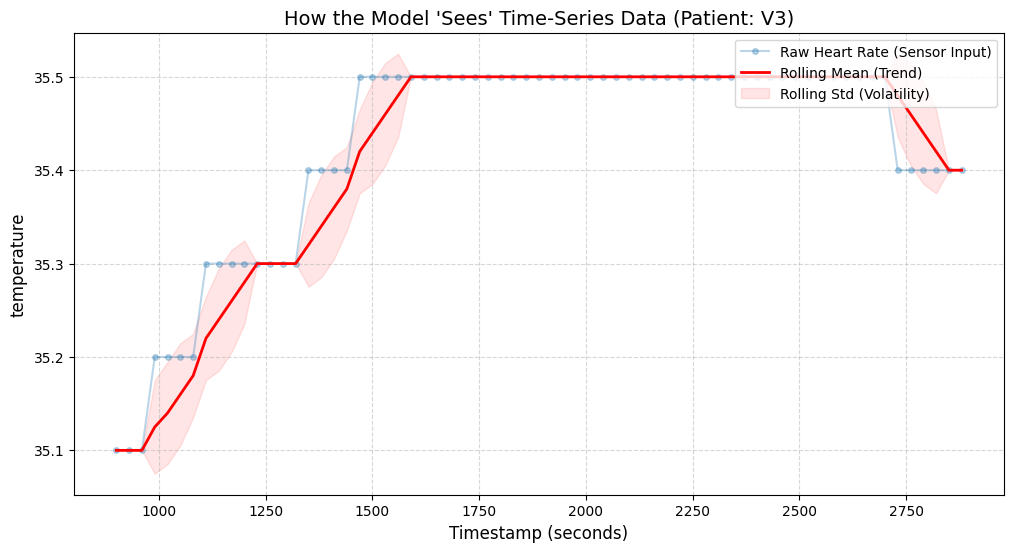

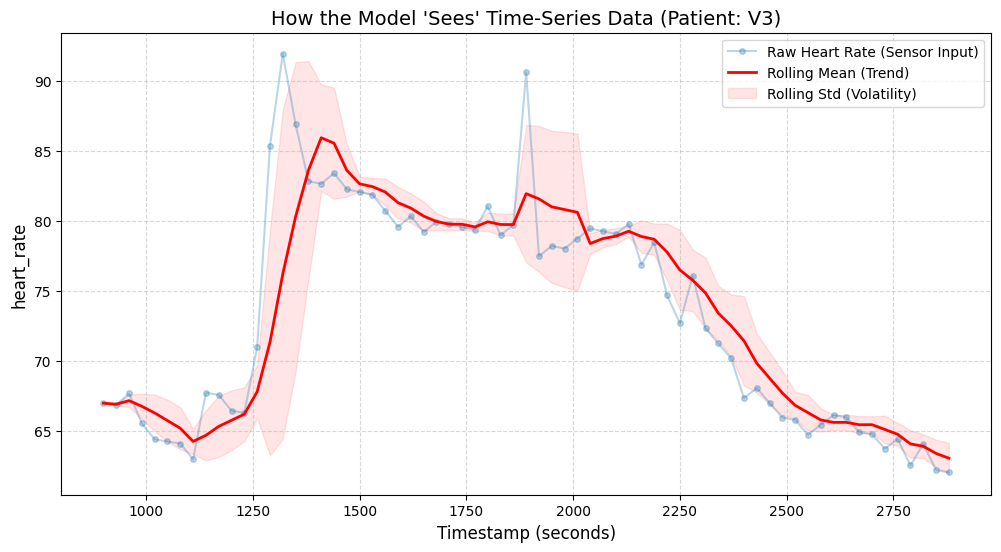

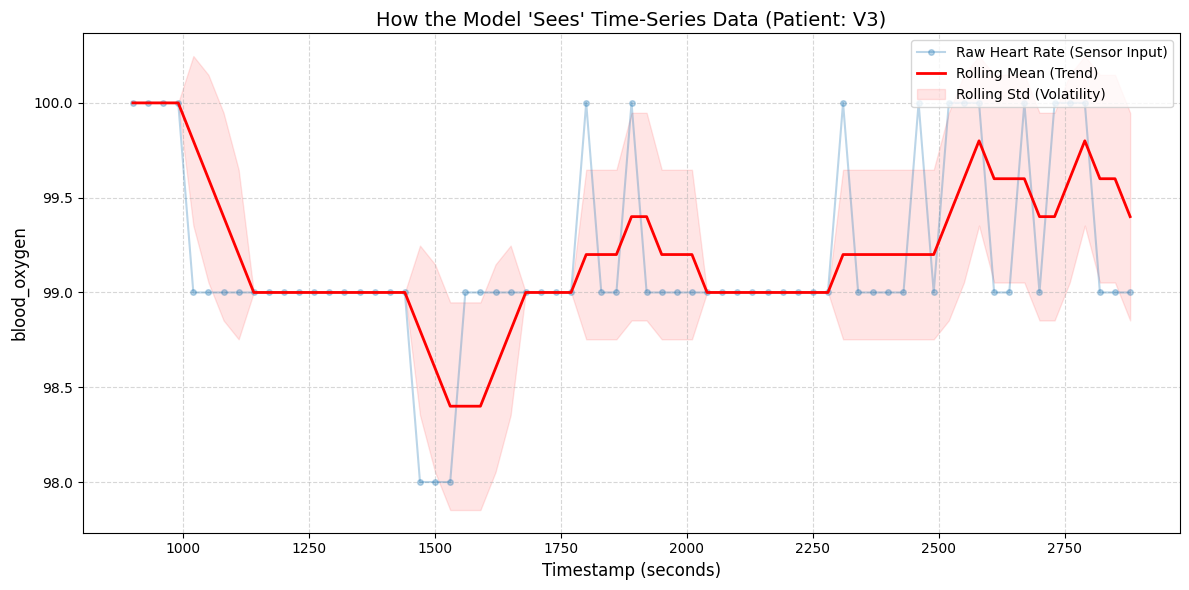

In [7]:
import os
from config import Config
import pandas as pd
import matplotlib.pyplot as plt
# 1. Load the dataset
data_path = Config.CLASSIFICATION["SAMPLEPATH"]
df = pd.read_csv(data_path)
numeric_cols = ['temperature', 'heart_rate', 'blood_oxygen']
# 2. Filter for a specific patient and sort by timestamp
patient_id = 'V3'
df_patient = df[df['patient_id'] == patient_id].sort_values('timestamp').head(100)

for c in numeric_cols:
    # 3. Create the visualization
    plt.figure(figsize=(12, 6))

    # Plot Raw Heart Rate
    plt.plot(df_patient['timestamp'], df_patient[c], 
            alpha=0.3, label='Raw Heart Rate (Sensor Input)', marker='o', markersize=4)

    # Calculate and Plot Rolling Mean (Trend)
    rolling_mean = df_patient[c].rolling(window=5, min_periods=1).mean()
    plt.plot(df_patient['timestamp'], rolling_mean, 
            color='red', linewidth=2, label='Rolling Mean (Trend)')

    # Calculate and Plot Rolling Std (Volatility)
    rolling_std = df_patient[c].rolling(window=5, min_periods=1).std()
    plt.fill_between(df_patient['timestamp'], 
                    rolling_mean - rolling_std,
                    rolling_mean + rolling_std, 
                    color='red', alpha=0.1, label='Rolling Std (Volatility)')
        
    # 4. Aesthetics
    plt.title(f"How the Model 'Sees' Time-Series Data (Patient: {patient_id})", fontsize=14)
    plt.xlabel("Timestamp (seconds)", fontsize=12)
    plt.ylabel(c, fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
